In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_SEED = 42

# Data Preprocessing

In [ ]:
# tweak train_alph.csv so that it matches coord.csv, train_alphabet1 contains the extracted coordinates from the 7GB training images folder
training_df= pd.read_csv("keypoint_classifier/Train_Alphabet1.csv")
training_df= training_df.sample(14000)
training_df= training_df.dropna()
training_df= training_df[training_df['label'].notna() & (training_df['label'].str.strip() != '')]
training_df.columns

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24',
       '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36',
       '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48',
       '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60',
       '61', '62', 'label'],
      dtype='object')

In [5]:
# create the mapping dictionary
alphabet_index_map = {chr(i): i - 65 for i in range(65, 91)}  # {'A': 0, 'B': 1', ..., 'Z': 25}
training_df['label_index'] = training_df['label'].map(alphabet_index_map)
training_df = training_df.dropna(subset=['label_index'])    # ensure that that there are no NaN values in label_index

# move 'label' column to the front
training_df = training_df[['label_index'] + [col for col in training_df.columns if col != 'label_index']]
training_df.columns



Index(['label_index', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10',
       '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22',
       '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34',
       '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46',
       '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58',
       '59', '60', '61', '62', 'label'],
      dtype='object')

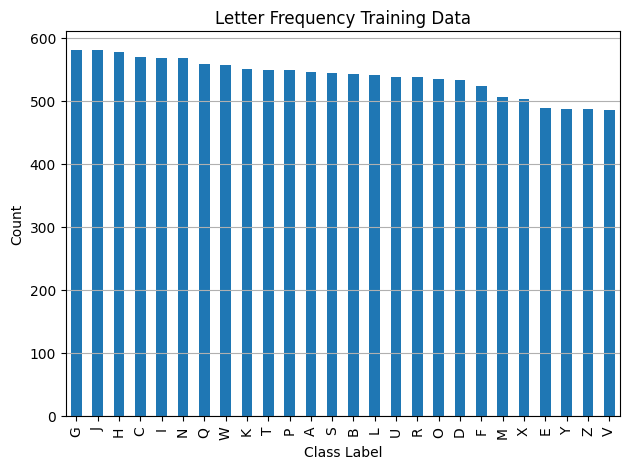

In [6]:
training_df['label'].value_counts().plot(kind='bar')
plt.title('Letter Frequency Training Data')
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()


/var/folders/nh/b84nc6pd1353r3vmzmt9rxw80000gn/T/ipykernel_77875/370323172.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_df = df.groupby('label').apply(lambda x: x.sample(n=130, random_state=42)).reset_index(drop=True)


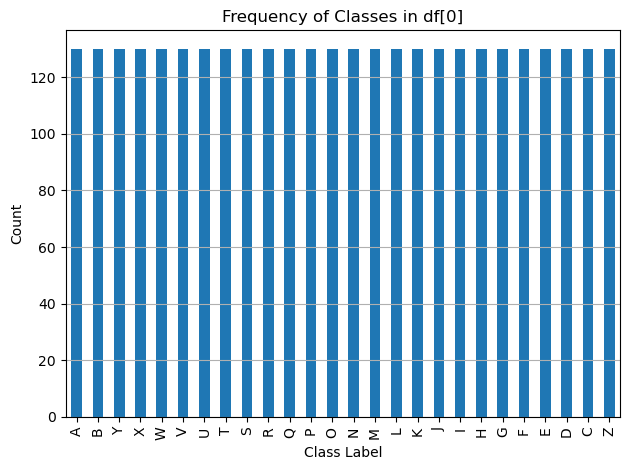

In [ ]:
# balance data - don't really need since we are stratifying 
balanced_df = df.groupby('label').apply(lambda x: x.sample(n=130, random_state=42)).reset_index(drop=True)
balanced_df['label'].value_counts().plot(kind='bar')
plt.title('Frequency of Classes in df[0]')
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()


In [7]:
# the 'label' column is only really needed for visualization and understanding the data
# since we're encoding it to 'label_index', we can drop it for now
training_df = training_df.drop(columns=['label'])

In [8]:
training_df.head

<bound method NDFrame.head of        label_index         0         1             2         3         4  \
8344          10.0  0.491672  0.815008  1.188142e-06  0.434350  0.744600   
15846         19.0  0.426682  0.680264 -5.332719e-07  0.501894  0.658615   
2821           3.0  0.543217  0.827453 -2.965593e-07  0.424489  0.771251   
12130         14.0  0.492213  0.804927  5.194663e-07  0.590323  0.693899   
7224           8.0  0.527546  0.697024 -3.946816e-07  0.603725  0.669544   
...            ...       ...       ...           ...       ...       ...   
19529         24.0  0.534824  0.903988 -1.116048e-06  0.429139  0.835389   
505            0.0  0.482201  0.771861 -8.186072e-07  0.396414  0.736695   
4700           5.0  0.507699  0.960715  7.693586e-07  0.430192  0.923480   
20318         25.0  0.553586  0.831353  2.418109e-07  0.605562  0.799413   
14469         17.0  0.495278  0.753114  9.609720e-07  0.562006  0.690854   

              5         6         7         8  ...       

In [ ]:
training_df.to_csv('training.csv', index=False, header=False) #index=False means don't write row numbers, header=False means don't write column names

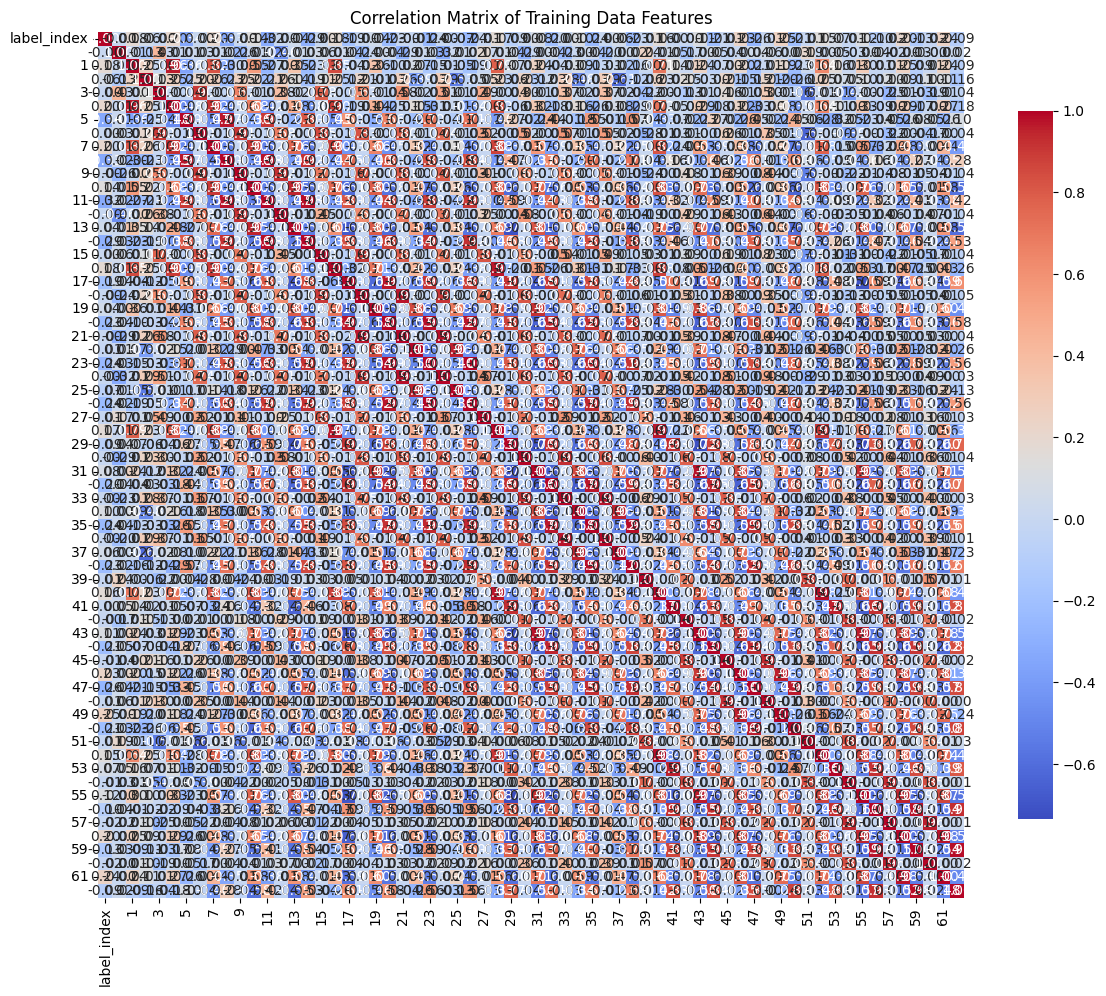

In [9]:
# correlation matrix
corr_matrix = training_df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix of Training Data Features')
plt.tight_layout()
plt.show()

In [ ]:
# omg ^^